## Data Processing

In [25]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from typing import Optional

In [26]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

#### Data Directory

In [27]:
RAW_CSV_PATH = "../data/raw/twcs.csv" if os.path.exists("../data/raw/twcs.csv") else "data/raw/twcs.csv"
PROCESSED_DIR = "../data/processed" if os.path.exists("../data") else "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)
print("Setup complete. Raw data path:", RAW_CSV_PATH)

Setup complete. Raw data path: ../data/raw/twcs.csv


#### Cleaning and Loading Data

In [28]:
def extract_amazon_pairs(raw_path, chunk_size = 150_000, target_brand = "AmazonHelp"):
    brand_tweets = []
    customer_tweets = []
    for idx, chunk in enumerate(pd.read_csv(RAW_CSV_PATH, chunksize = chunk_size, low_memory = False)):
        # Deal with brand tweets
        brand_chunk = chunk[chunk['author_id'] == target_brand]
        if not brand_chunk.empty:
            brand_tweets.append(brand_chunk)
        #Deal with customer tweets
        customer_chunk = chunk[(chunk['inbound'] == True) & (chunk['response_tweet_id'].notna())]
        if not customer_chunk.empty:
            customer_tweets.append(customer_chunk[['tweet_id', 'author_id', 'text', 'response_tweet_id']])
        if (idx + 1) % 5 == 0:
            print(f"Processed {(idx + 1) * chunk_size} rows!")
    df_brand = pd.concat(brand_tweets, ignore_index = True)
    df_customer = pd.concat(customer_tweets, ignore_index = True)

    df_brand['in_response_to_tweet_id'] = pd.to_numeric(df_brand['in_response_to_tweet_id'], errors = 'coerce')
    df_customer['tweet_id'] = pd.to_numeric(df_customer['tweet_id'], errors = 'coerce')

    print('Merging customer inquiry with brand reply')
    merged = pd.merge(df_customer, df_brand, left_on = 'tweet_id', right_on = 'in_response_to_tweet_id', suffixes = ('_customer', '_brand'))
    return merged

In [29]:
df_pairs_raw = extract_amazon_pairs(RAW_CSV_PATH)
print(f"\n[✔] Total matched pairs found: {len(df_pairs_raw):,}")

Processed 750000 rows!
Processed 1500000 rows!
Processed 2250000 rows!
Merging customer inquiry with brand reply

[✔] Total matched pairs found: 168,814


In [30]:
def clean_tweet(text):
    if not isinstance(text, str):
        return None
    else:
        # Clean @mentions
        cleaned = re.sub(r"^(@\w+\s*)+", "", text)
        # CLean whitespaces
        cleaned = re.sub(r"\s+", " ", cleaned).strip()
        return cleaned

df_pairs = pd.DataFrame({
    "customer_tweet_id": df_pairs_raw["tweet_id_customer"],
    "customer_text": df_pairs_raw["text_customer"],
    "customer_clean":df_pairs_raw["text_customer"].apply(clean_tweet),
    "brand_tweet_id": df_pairs_raw["tweet_id_brand"],
    "brand_text": df_pairs_raw["text_brand"],
    "brand_clean": df_pairs_raw["text_brand"].apply(clean_tweet),
    "created_at": df_pairs_raw["created_at"]
})

# Filter out nosiy tweets that are under 4 words and duplicates
df_pairs = df_pairs[df_pairs["customer_clean"].str.split().str.len() >= 4]
df_pairs = df_pairs[df_pairs["brand_clean"].str.split().str.len() >= 4]
df_pairs = df_pairs.drop_duplicates(subset=["customer_clean"]).reset_index(drop=True)
print(f"Cleaned unique conversation pairs: {len(df_pairs):,}")
df_pairs[["customer_clean", "brand_clean"]].head(5)

Cleaned unique conversation pairs: 137,644


,customer_clean,brand_clean
0,3 different people have given 3 different answ...,We'd like to take a further look into this wit...
1,Way to drop the ball on customer service @1158...,I'm sorry we've let you down! Without providin...
2,I want my amazon payments account CLOSED. dm m...,I am unable to affect your account via Twitter...
3,"Okay, danke für die Info",Wir haben zu danken. Schönen Abend noch. ^JS
4,"also, beim Addams Family-Film in Prime sind Bi...","Hi, wir erhalten die Filme/Serien so vom jewei..."


#### Topic Analysis

C:\Users\Roschlynn\AppData\Local\Temp\ipykernel_6760\3369381065.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_words, x = 'Frequency', y = 'Keywords', palette = 'viridis')


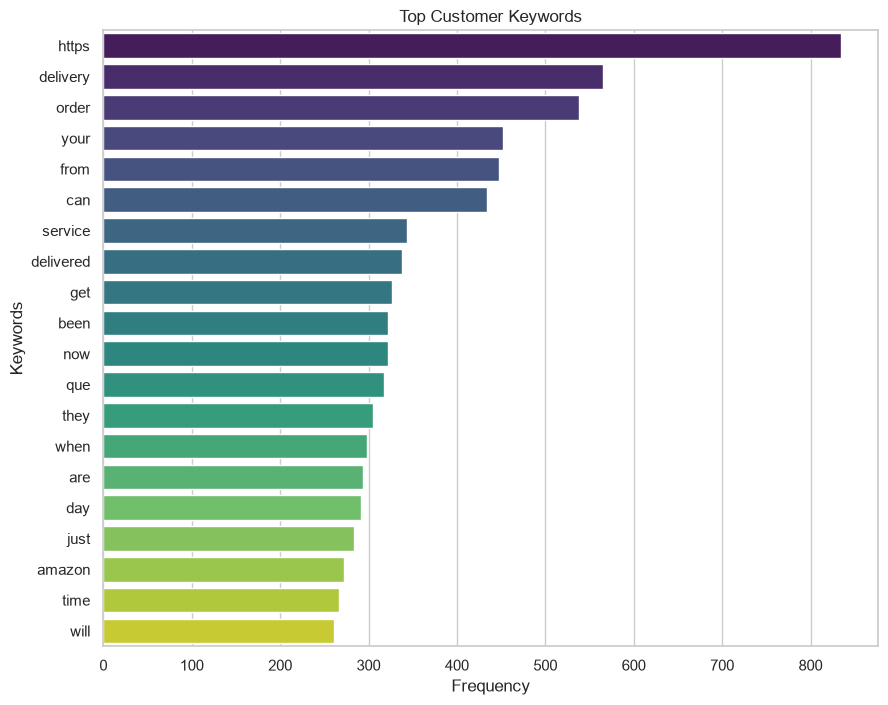

In [31]:
stopwords = {"the", "a", "an", "i", "my", "to", "and", "is", "in", "it", "you", "for", "on", "of", "with", "have", "me", "this", "that", "at", "be", "was", "not", "but", "so"}

words = [
    word.lower()
    for text in df_pairs['customer_clean'].sample(5000, random_state = 42)
    for word in re.findall(r"\b[a-z]{3,}\b", text)
    if word.lower() not in stopwords
]

top_words = pd.DataFrame(Counter(words).most_common(20), columns = ['Keywords', 'Frequency'])

plt.figure(figsize = (10, 8))
sns.barplot(data = top_words, x = 'Frequency', y = 'Keywords', palette = 'viridis')
plt.title('Top Customer Keywords')
plt.show()

#### Analysis of the dataset

Based on frequency analysis of the dataset, here's what I can conclude
1. **Order and Delivery Queries**: Questions regarding order tracking, delay of shipments, reasons for late deliveries, courier delivery timeframe
2. **Links**: Customers often post HTTP links to products, the order details. On twitter, when customers attach screenshots of their delivery orders, twitter converts it to links which shows up as HTTP in the graph and cannot be used for analysis.
3. **que**: Customers converse with amazon in various languages including spanish. que stands for what in spanish.

The rest are just left over filters that need to be filtered out. In addition to this, there are several queries about when will the orders be delivered, service queries and amazon support related queries.


In [34]:
def clean_text_further(text):
    if not isinstance(text, str):
        return None
    else:
        # Remove HTTP and HTTPS links
        text = re.sub(r"https?://\S+|www\.\S+", "", text)
        # Remove @mentions if they exist
        text = re.sub(r"@\w+", "", text)
        # Lowercase & Strip
        return text.lower().strip()
    
    # New stopwords list
new_stop_words = {"the", "a", "an", "i", "my", "to", "and", "is", "in", "it", "you", "your", 
    "for", "on", "of", "with", "have", "me", "this", "that", "at", "be", "was", 
    "not", "but", "so", "from", "can", "get", "been", "now", "they", "when", 
    "are", "just", "amazon", "will", "all", "what", "how", "has", "had", "out",
    "there", "one", "would", "about", "did", "got", "we", "if", "or", "as", "by"}

cleaned_sample = df_pairs['customer_clean'].apply(clean_text_further).sample(5000, random_state = 42)

problem_words = [
        word
        for text in cleaned_sample
        for word in re.findall(r"\b[a-z]{3,}\b", text)
        if word not in new_stop_words and len(word) > 2
    ]

In [35]:
top_words_new = pd.DataFrame(Counter(problem_words).most_common(20), columns = ['Keywords', 'Frequency'])

C:\Users\Roschlynn\AppData\Local\Temp\ipykernel_6760\3475555647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_words_new, x = 'Frequency', y = 'Keywords', palette = 'viridis')


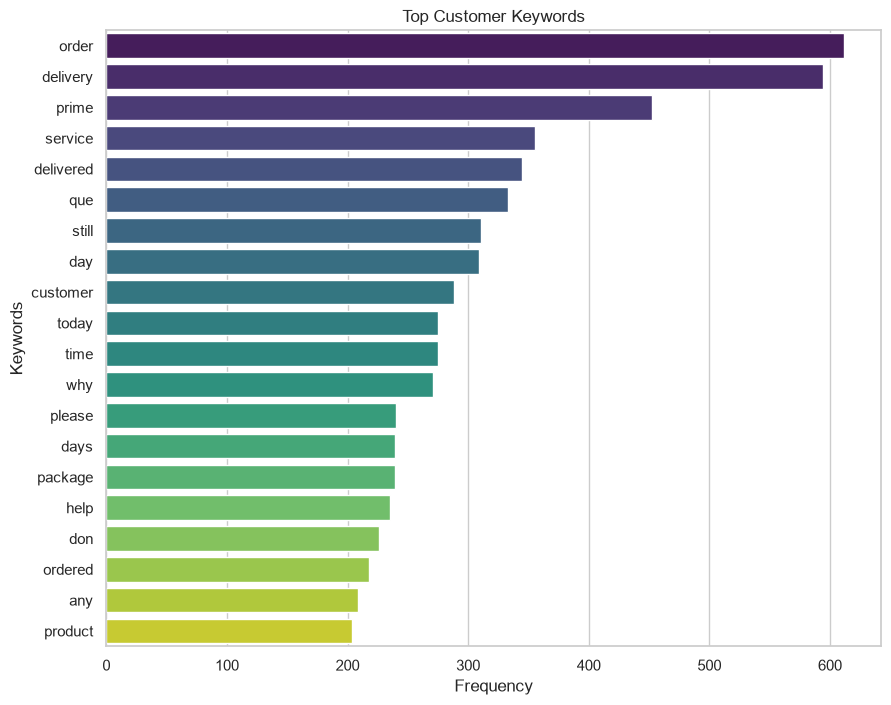

In [36]:
plt.figure(figsize = (10, 8))
sns.barplot(data = top_words_new, x = 'Frequency', y = 'Keywords', palette = 'viridis')
plt.title('Top Customer Keywords')
plt.show()

#### Analysis of the new graph
Top words are order, delivery, prime, package which shows the most common queries are related to order and delivery, prime and package services. Words like why, please, service, still, que show strong dissattisfaction of customers on the amazon platform.

For our model we can consider order_tracking_delay as a majority class. Any customer anger, dissatisfaction and matters of urgency should trigger immediate escalation to a customer support agent. 

#### Preparing new dataset for pipeline

In [39]:
def clean_pipeline(text):
    if not isinstance(text, str):
        return None
    else:
        # Clear http and https links
        text = re.sub(r"https?://\S+|www\.\S+", "", text)
        # Remove @mentions
        text = re.sub(r"@\w+", "", text)
        # Clear spaces
        return re.sub(r"\s+", " ", text).strip()

df_pairs_clean = df_pairs.copy()
df_pairs_clean['customer_clean'] = df_pairs_clean['customer_text'].apply(clean_pipeline)
df_pairs_clean['brand_clean'] = df_pairs_clean['brand_text'].apply(clean_pipeline)

df_pairs_clean = df_pairs_clean[df_pairs_clean['customer_clean'].str.split().str.len() >= 4]
df_pairs_clean = df_pairs_clean[df_pairs_clean['brand_clean'].str.split().str.len() >= 4]

df_pairs_clean = df_pairs_clean.drop_duplicates(subset = ['customer_clean']).reset_index(drop = True)
print(f"[✔] New df_pairs_clean ready with {len(df_pairs_clean):,} high-quality pairs!")
df_pairs_clean[["customer_clean", "brand_clean"]].head(3)

[✔] New df_pairs_clean ready with 136,737 high-quality pairs!


,customer_clean,brand_clean
0,3 different people have given 3 different answ...,We'd like to take a further look into this wit...
1,Way to drop the ball on customer service so pi...,I'm sorry we've let you down! Without providin...
2,I want my amazon payments account CLOSED. dm m...,I am unable to affect your account via Twitter...


#### Historical Analysis

In [41]:
# This code block runs analysis on what amazon does and how it resolves queries
sample_inspect = df_pairs_clean.sample(5, random_state = 42)

for idx, (_, row) in enumerate(sample_inspect.iterrows(), start=1):
    print(f"==================== Example {idx} ====================")
    print(f" CUSTOMER:\n{row['customer_clean']}\n")
    print(f" AMAZON REPLY:\n{row['brand_clean']}")
    print("=" * 55 + "\n")

==================== Example 1 ====================
 CUSTOMER:
I'm not sure.i assumed they would be all the same courier.

 AMAZON REPLY:
I'm sorry about this. We want to be sure you are receiving your parcels when they are expected. Please reach out to us directly here so that we can take a look into this for you: We'd like to help! ^ZW

==================== Example 2 ====================
 CUSTOMER:
You really want to keep my money? I'm waiting for 3 months now!!!!!!! Please resolve the case 4534957581

 AMAZON REPLY:
I'm sorry for any trouble. Are you a seller on Amazon.in or ^RW

==================== Example 3 ====================
 CUSTOMER:
It’s like the battery I ordered asked to be upgraded to Business Class with extra leg room. Bonkers box choice,

 AMAZON REPLY:
We're always looking for ways to improve, Henry, and providing your packing feedback here will help: . Keep us posted if you need us! Thanks! ^FR

==================== Example 4 ====================
 CUSTOMER:
A special

#### Export the processed data and process a 5000 sample golden dataset

In [45]:
PROCESSED_DIR = "../data/processed" if os.path.exists("../data") else "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [46]:
full_csv_path = os.path.join(PROCESSED_DIR, "amazon_help_pairs_full.csv")
df_pairs_clean.to_csv(full_csv_path, index=False)
print(f"[✔] 1. Saved FULL cleaned dataset ({len(df_pairs_clean):,} pairs) to:\n    -> {full_csv_path}")

[✔] 1. Saved FULL cleaned dataset (136,737 pairs) to:
    -> ../data/processed\amazon_help_pairs_full.csv


In [47]:
sample_5k_path = os.path.join(PROCESSED_DIR, "amazon_help_pairs_sample_5k.csv")
df_5k = df_pairs_clean.sample(
    n=min(5000, len(df_pairs_clean)), 
    random_state=42
).reset_index(drop=True)
df_5k.to_csv(sample_5k_path, index=False)
print(f"\n[✔] 2. Saved 5,000-pair sample ({len(df_5k):,} pairs) to:\n    -> {sample_5k_path}")


[✔] 2. Saved 5,000-pair sample (5,000 pairs) to:
    -> ../data/processed\amazon_help_pairs_sample_5k.csv
